## **Problem Statement**:

> Take two long input of integers and implement two versions of divide and conquer algorithm. Check at what value of n one performs better than other.

**Theoretical Background:**

> Theoretically, the time complexity of first algorithm(naive multiplication) is  ${O(n^2)}$ and the time complexity of second algorithm(Karatsuba's algorithm) is ${O(n^{1.58})}$.





## **Developer Details:**


> **Name:** *Rahul Biswas*
<br> **Date:** *20-08-2025*

> **File Name:** *CSPC901_AGLAB_Assignment2_RahulBiswas_16.py*

> <u>*M.TECH COMPUTER SCIENCE AND ENGINEERING*</u><br><u>***University of Calcutta***</u>



## **Source Code**

### **Library Files:**


> **secrets:** All possible values are equally likely to be generated and No statistical bias toward certain numbers.



> **time:** For the calculation of computational time.

> **math:** Number of digits in a given number.

> **matplotlib.plot:** For the visualization of the result.









In [57]:
import secrets
import time
import math
import matplotlib.pyplot as plt

### **Naive algorithm:**
Theoretically, Time complexity is ${O(n^2)}$.
<br>Recurrance relation is
$$
T(n) = 4T(\frac{n}{2})+\Theta(n)
$$

In [41]:
def naive_mult(x, y):
    # Handle negative numbers
    sign = 1
    if x < 0:
        x = -x
        sign = -sign
    if y < 0:
        y = -y
        sign = -sign

    # Base case: use naive multiplication for small numbers
    if x < 10 or y < 10:
        return x*y

    # Calculate number of digits without string conversion
    n = max(int(math.log10(x)) + 1 if x > 0 else 1,
            int(math.log10(y)) + 1 if y > 0 else 1)
    half = n // 2

    # Split the numbers
    divisor = 10 ** half
    a = x // divisor
    b = x % divisor
    c = y // divisor
    d = y % divisor

    # Recursive calls
    ac = naive_mult(a, c)
    bd = naive_mult(b, d)
    ad = naive_mult(a,d)
    bc = naive_mult(b,c)

    return (ac * (10 ** (2 * half)) + (ad+bc)*10**(half) + bd) * sign

### **Karatsuba's algorithm:**
Theoretically, Time complexity is ${O(n^{1.58})}$.
<br>Recurrance relation is
$$
T(n) = 3T(\frac{n}{2})+\Theta(n)
$$

In [42]:
def karatsuba_mult(x, y):
    """Karatsuba multiplication with threshold for switching to naive"""
    # Handle negative numbers
    sign = 1
    if x < 0:
        x = -x
        sign = -sign
    if y < 0:
        y = -y
        sign = -sign

    # Base case: use naive multiplication for small numbers
    if x < 10 or y < 10:
        return x*y

    # Calculate number of digits without string conversion
    n = max(int(math.log10(x)) + 1 if x > 0 else 1,
            int(math.log10(y)) + 1 if y > 0 else 1)
    half = n // 2

    # Split the numbers
    divisor = 10 ** half
    a = x // divisor
    b = x % divisor
    c = y // divisor
    d = y % divisor

    # Recursive calls
    ac = karatsuba_mult(a, c)
    bd = karatsuba_mult(b, d)
    ad_plus_bc = karatsuba_mult(a + b, c + d) - ac - bd

    return (ac * (10 ** (2 * half)) + ad_plus_bc * (10 ** half) + bd) * sign


### **Random Number Generator**:

> Generates a random number with n digits from a uniform distribution.



In [48]:
def secure_random_ndigits(n):
    """Cryptographically secure random number with n digits"""
    if n <= 0:
        raise ValueError("Number of digits must be positive")
    range_start = 10**(n-1)
    range_end = (10**n) - 1
    return secrets.randbelow(range_end - range_start + 1) + range_start

### **Benchmark Time Calcutator**:


> Calculates the average running/computation time for different algorithms.



In [43]:
def benchmark_multiplication_time(n, trials=1000):
    total_naive_ns = 0
    total_karatsuba_ns = 0

    for _ in range(trials):
        number1 = secure_random_ndigits(n)
        number2 = secure_random_ndigits(n)

        start_naive = time.perf_counter_ns()
        _ = naive_mult(number1, number2)
        elapsed_naive = time.perf_counter_ns() - start_naive
        total_naive_ns += elapsed_naive

        start_karatsuba = time.perf_counter_ns()
        _ = karatsuba_mult(number1, number2)
        elapsed_karatsuba = time.perf_counter_ns() - start_karatsuba
        total_karatsuba_ns += elapsed_karatsuba

    avg_naive_ms = (total_naive_ns / trials) / 1e6
    avg_karatsuba_ms = (total_karatsuba_ns / trials) / 1e6

    return (avg_naive_ms, avg_karatsuba_ms)


### **Result**:


> Table of comparison showing which divide-and-conquer based multiplication algorithm in faster with different number of digits.



> Graph of number of digits vs. computation time.





####**Table of Comparison**:


> It shows the comparison between two divide-and-conquer algorithms in terms of computation time.



In [49]:
def print_comparison_table(digit_lengths, naive_times, karatsuba_times):
    """Print a formatted comparison table"""
    print("\nMultiplication Algorithm Comparison:")
    print("-" * 80)
    print(f"{'Digits':<8} | {'Naive (ms)':<12} | {'Karatsuba (ms)':<15} | {'Faster':<8} | {'Speedup':<10}")
    print("-" * 80)

    for i, length in enumerate(digit_lengths):
        naive_time = naive_times[i]
        karatsuba_time = karatsuba_times[i]

        faster = "Naive" if naive_time < karatsuba_time else "Karatsuba"
        ratio = max(naive_time, karatsuba_time) / min(naive_time, karatsuba_time)
        speedup_direction = "× slower" if faster == "Naive" else "× faster"

        print(f"{length:<8} | {naive_time:.6f}    | {karatsuba_time:.6f}       | "
              f"{faster:<8} | {ratio:.2f}{speedup_direction}")

#### **Graph of comparison**:



> It shows the comparison between two divide-and-conquer algorithms in terms of computation time using graph.




In [58]:
def plot_results(digit_lengths, naive_times, karatsuba_times):
    """Plot the comparison results"""
    plt.figure(figsize=(12, 8))

    # Linear scale
    plt.subplot(2, 1, 1)
    plt.plot(digit_lengths, naive_times, 'bo-', label='Naive (O(n²))', linewidth=2)
    plt.plot(digit_lengths, karatsuba_times, 'ro-', label='Karatsuba (O(n¹·⁵⁸))', linewidth=2)
    plt.xlabel('Number of Digits')
    plt.ylabel('Time (ms)')
    plt.title('Multiplication Time Comparison')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig('multiplication_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

### **Main function**:

In [61]:
def main():
  digit_lengths = [5,10,15,20,25,30,35,40,45,50,60,70,80,90,100,500,1000]
  naive_time = []
  karatsuba_time = []
  for length in digit_lengths:
     n_time,k_time,t_n_time =benchmark_multiplication_time(length)
     naive_time.append(n_time)
     karatsuba_time.append(k_time)
  print_comparison_table(digit_lengths,naive_time,karatsuba_time)
  plot_results(digit_lengths,naive_time,karatsuba_time)


Multiplication Algorithm Comparison:
--------------------------------------------------------------------------------
Digits   | Naive (ms)   | Karatsuba (ms)  | Faster   | Speedup   
--------------------------------------------------------------------------------
5        | 0.008342    | 0.012075       | Naive    | 1.45× slower
10       | 0.030455    | 0.034684       | Naive    | 1.14× slower
15       | 0.076947    | 0.060650       | Karatsuba | 1.27× faster
20       | 0.129333    | 0.113721       | Karatsuba | 1.14× faster
25       | 0.195473    | 0.145334       | Karatsuba | 1.34× faster
30       | 0.310515    | 0.188358       | Karatsuba | 1.65× faster
35       | 0.399551    | 0.269216       | Karatsuba | 1.48× faster
40       | 0.493338    | 0.336018       | Karatsuba | 1.47× faster
45       | 0.641622    | 0.397487       | Karatsuba | 1.61× faster
50       | 0.793100    | 0.446178       | Karatsuba | 1.78× faster
60       | 2.033926    | 0.917528       | Karatsuba | 2.22× faster

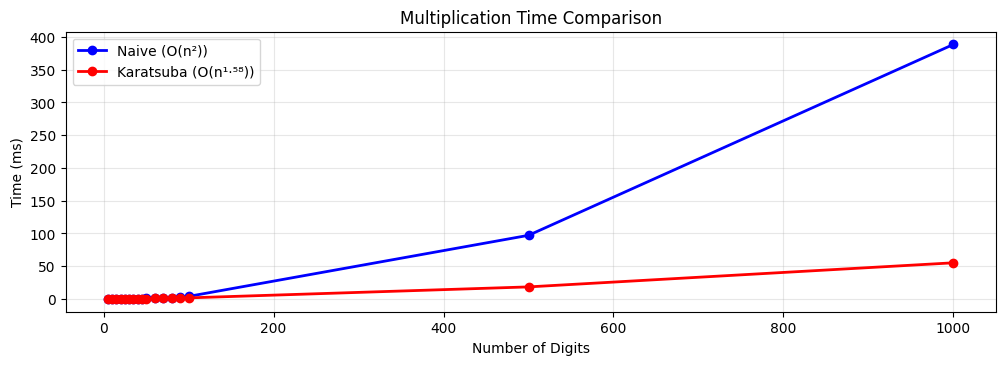

In [62]:
if __name__ == "__main__":
    main()

## **Conclusion**:



> Between the two divide-and-conquer-based multiplication methods, Karatsuba's algorithm is faster as it requires only 3 recursive calls. However, for smaller numbers of digits, the naive algorithm is faster due to the extra operations (additions and subtractions) in Karatsuba. The crossover point is around 15 digits. (In Python, multiplication is optimized using C)

>Experiments show that the naïve algorithm is $O(n^2)$, while Karatsuba's algorithm is $O(n^{1.58})$, which matches the theoretical results.



